In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
train_path = '/content/drive/MyDrive/AI Worksheet/devnagari digit/DevanagariHandwrittenDigitDataset/Train'
test_path = '/content/drive/MyDrive/AI Worksheet/devnagari digit/DevanagariHandwrittenDigitDataset/Test'

In [12]:
!pip install tensorflow

In [11]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

IMG_SIZE = 28
NUM_CLASSES = 10

def load_data(data_dir):
    X = []
    y = []

    for label in os.listdir(data_dir):
        label_path = os.path.join(data_dir, label)

        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)

                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img_array = np.array(img) / 255.0

                X.append(img_array)
                # Extract the digit from 'digit_X' format
                try:
                    # Assuming labels are like 'digit_0', 'digit_1', ..., 'digit_9'
                    digit_str = label.split('_')[1]
                    y.append(int(digit_str))
                except (IndexError, ValueError):
                    print(f"Warning: Could not parse label '{label}'. Skipping images in {label_path}")
                    continue

    return np.array(X), np.array(y)

# Load data
X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Flatten
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# One-hot encoding
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

print("Data Loaded Successfully!")

Data Loaded Successfully!


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
73/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2912 - loss: 1.8084

81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4872 - loss: 1.4751 - val_accuracy: 0.0000e+00 - val_loss: 5.3847
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7980 - loss: 0.5517 - val_accuracy: 0.0000e+00 - val_loss: 5.7214
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9033 - loss: 0.3233 - val_accuracy: 3.8595e-04 - val_loss: 5.6433
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9391 - loss: 0.2234 - val_accuracy: 0.0012 - val_loss: 5.7879
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9499 - loss: 0.1765 - val_accuracy: 0.0178 - val_loss: 5.7500
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9587 - loss: 0.1470 - val_accuracy: 0.0266 - val_loss: 5.8337


In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4513 - loss: 3.1412
Test Accuracy: 0.45133334398269653


In [18]:
model.save('/content/drive/MyDrive/devnagari_model.h5')

from tensorflow.keras.models import load_model

loaded_model = load_model('/content/drive/MyDrive/devnagari_model.h5')

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4513 - loss: 3.1412
Loaded Model Accuracy: 0.45133334398269653


In [19]:
predictions = loaded_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Predictions:", y_pred[:10])
print("Actual:", y_true[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions: [1 1 1 1 1 1 1 1 1 1]
Actual: [1 1 1 1 1 1 1 1 1 1]


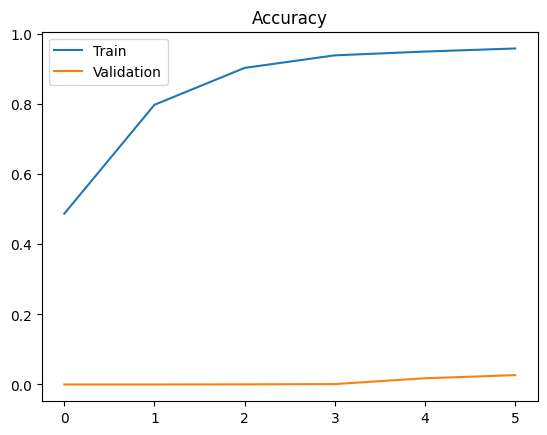

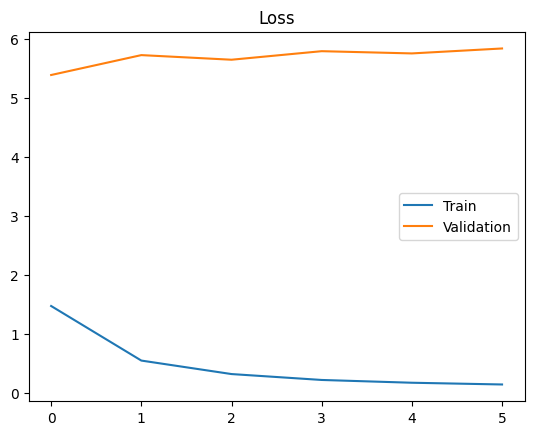

In [20]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()